to execute the program you can clic on a coding cell and use shift+enter to execute it 

#### Import packages and functions necessary for the program

In [1]:
#%% import
import matplotlib.pyplot as plt
import pandas as pd
import statistics as stat
import numpy as np
# import matplotlib.colors as mcolors
from tkinter import *
from tkinter import filedialog
import scipy as sci
from scipy.optimize import curve_fit

#%% functions
def openFile():
    """open a window to choose a file and return the path"""
    filepath=filedialog.askopenfilename()
    return filepath

def smoothing(curve,averaging):
    """create an empty list 'smoothed', take a list of values 'curve', for each point in 'curve' with averaging<index<len(curve)-averaging, add to 'smoothed' the mean of 'averaging' points before and after the point. For extremities, it does only on one side."""
    smoothed=[]
    for index in range(0,len(curve)):
        if averaging<=index<len(curve)-averaging:
            smoothed.append(stat.mean(curve[index-averaging:index+averaging+1]))
        elif index>=len(curve)-averaging:
                smoothed.append(stat.mean(curve[index-averaging:index]))
        else:
            smoothed.append(stat.mean(curve[index:index+averaging]))
    smoothed=np.array(smoothed)
    return smoothed

def logistic(x,A,m,k,c):
    """modelise the logistic curve equation, c respresents the initial value, A is the Amplitude of the transition, m is the middle of the transition and k influence the span of the transition"""
    y=c+A/(1+np.exp(-k*(x-m)))
    return y

def report(liste,experiments,message_to_report):
    """take a list containing the tags that satisfy a condition, create a dictionary that associates the experiment tag to a custom message if it is in the list."""
    dico={}
    for tag in experiments:
        if tag in liste:
            dico[tag]=message_to_report
        else:
            dico[tag]=np.nan  
    return dico

def pick_type(message,types):
    """call the function to know which modified curve types are available and allow to pick one."""
    print(message,list(types.keys()))
    select=str(input())
    if select in list(types.keys()):
        return select
    else:
        raise ValueError(select,'is not in the list')

def choose_indiv_curve(experiments):
    """allow to pick curves by copy pasting the labels of interest."""
    liste=[]
    print('curve labels: ',experiments)
    label=' '
    i=0
    print('copy paste curve label:')
    while label!='':
        print('curve label',i+1,': press enter to end the selection')
        i+=1
        label=str(input())
        if label!='':
            if label not in experiments:
                print('the label is not in the list')
            else:
                liste.append(label)
    return liste

def choose_tag_based(experiments):
    """select elements in a list containing the required string."""
    liste=[]
    print('curve labels: ',experiments)
    print('write a subword to look in the labels')
    target=' '
    i=0
    while target!='':
        print('target subword',i+1,': ')
        i+=1
        target=str(input())
        if target!='':
            for tag in experiments:
                if target in tag and tag not in liste:
                    liste.append(tag)
        print('current selection: ',liste,' press enter to end the selection')
    return liste

# allow to pick the controls based on two methods
def pick_curve(experiments):
    """allow to choose how to do a curve selection between target based or individually."""
    liste=[]
    print('do you prefer to copy single curve labels or to look for a keyword in the labels ? "single"/"keyword"')
    pick=str(input())
    if pick=="single":
        liste=choose_indiv_curve(experiments)
    elif pick=="keyword":
        liste=choose_tag_based(experiments)
    else:
        print('error')
    return liste

# normalising function based on a predefined maxi and mini
def normalise(curve,maxi,mini):
    """create an array and fill it with the normalisation based on the mini and maxi in the arguments."""
    normal=[]
    curve=np.array(curve)
    normal=(curve-mini)/(maxi-mini)
    return normal

#other varibales
types={}

#### Import the data from a csv or excel file

it will make a window open up to choose the excel / csv file. The file to be open should contain the curves as columns with the header on top

In [2]:
#%% load data
# open a window to choose the data file

button=Button(text='Browse', command=openFile)
button.pack()
window=Tk()
window.mainloop()
Filename=openFile()

# read the file depending of its type
if Filename[-4:]=='.csv':
    data=pd.read_csv(Filename, encoding='iso8859_7')
else:
    data=pd.read_excel(Filename)

# store place and name of the file
slash=[pos for pos, char in enumerate(Filename) if char == '/']
place=Filename[0:slash[-1]+1]
name=Filename[slash[-1]+1:[pos for pos, char in enumerate(Filename) if char == '.'][0]]
print(data)


     Time [s]  Control 1  Control 2  Control 3  10% 15μM seed 1  \
0         0.0       2088       2002       1954             3264   
1       300.1       2031       1990       1978             3419   
2       600.1       1836       2023       1942             3377   
3       900.1       1861       2124       1900             3348   
4      1200.2       1798       1972       2037             3394   
..        ...        ...        ...        ...              ...   
233   69908.6      22449      26023       5417            30865   
234   70208.6      25162      26452       5393            33518   
235   70508.7      23669      26597       5852            33134   
236   70808.7      25612      25673       5750            32052   
237   71108.8      24210      26938       5632            28508   

     10% 15μM seed 2  10% 15μM seed 3  40% 15μM seed 1  40% 15μM seed 2  \
0               3174             2997             7755             7876   
1               3179             3051        

#### Find time column and give labels to each curve

In [3]:
#%% format time and curve names
# find time
for colonne in data.columns:
    if 'time' in colonne or 'Time' in colonne:
        time=np.array(pd.Series(data[colonne]).dropna())
        l=len(time)
        if '[h]' in colonne: # convert time to second if it's in hour
            time=time*3600
        break

# exclude temperature and store labels into experiments as a tuple
experiments=[]
for colonnes in data.columns:
    if colonnes!=colonne:
        if 'temp' in colonnes or 'Temp' in colonnes:
            pass
        else:
            experiments.append(colonnes.strip())
n=len(experiments)
experiments=tuple(experiments)
print('Here are the curve names: \n',list(experiments))


Here are the curve names: 
 ['Control 1', 'Control 2', 'Control 3', '10% 15μM seed 1', '10% 15μM seed 2', '10% 15μM seed 3', '40% 15μM seed 1', '40% 15μM seed 2', '40% 15μM seed 3', '10% 25μM seed 1', '10% 25μM seed 2', '10% 25μM seed 3', '40% 25μM seed 1', '40% 25μM seed 2', '40% 25μM seed 3']


#### Make a graphics with all curves contained in the datafile

every graph can be saved by doing right clic save

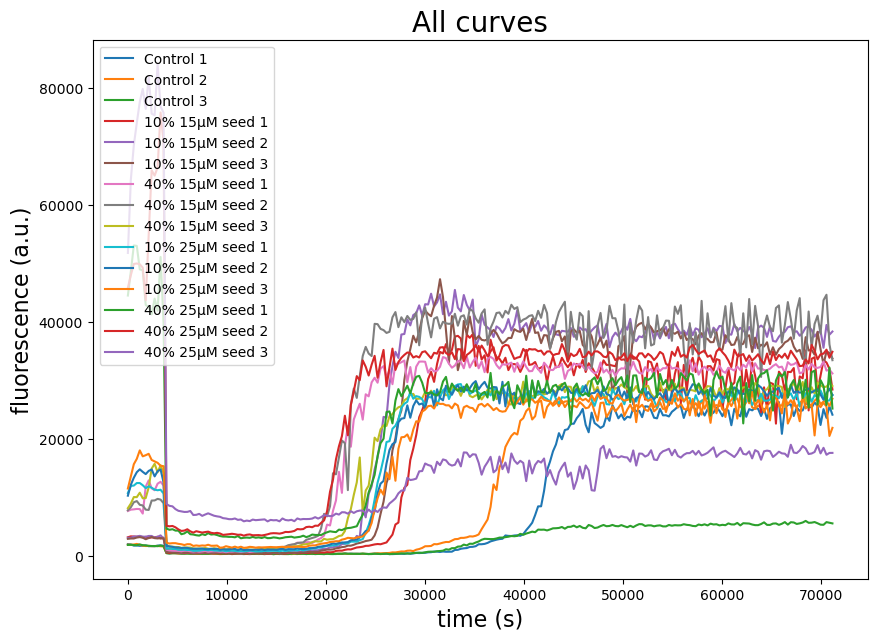

In [4]:
#%% format curves and plot them
# create a dictionnary with raw curves associated to their label
curves={}
for tag in experiments:
    curves[tag]=np.array(data[tag][:l])
    if len(data[tag])>l:
        print(f'the curve {tag} had more points than the time has')
types['raw']=curves
# plot all raw curves
fig,ax = plt.subplots(figsize=(10,7))
for tag in experiments:
    ax.plot(time,curves[tag],label=tag)
plt.legend()
plt.ylabel("fluorescence (a.u.)",fontsize=16)
plt.xlabel("time (s)",fontsize=16)
plt.title('All curves',fontsize=20)
plt.show()

run if you need a different title

graphic title: custom title


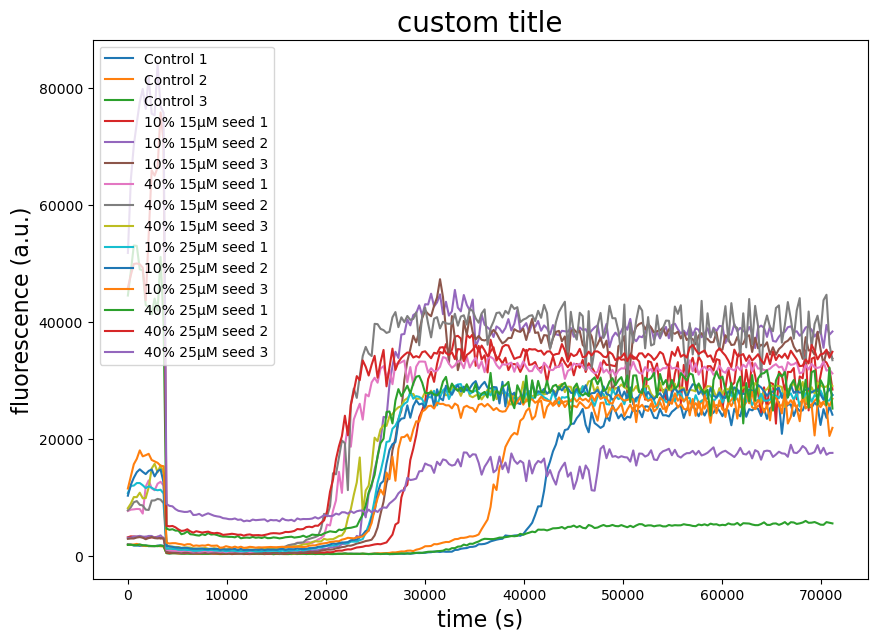

In [5]:
title=str(input('graphic title: '))
fig,ax = plt.subplots(figsize=(10,7))
for tag in experiments:
    ax.plot(time,curves[tag],label=tag)
plt.legend()
plt.ylabel("fluorescence (a.u.)",fontsize=16)
plt.xlabel("time (s)",fontsize=16)
plt.title(title,fontsize=20)
plt.show()

#### Calculate and graph smoothed curve

smoothing is done by averaging each point over a number of neighboring points before and after corresponding to the variable "averaging" that can be changed

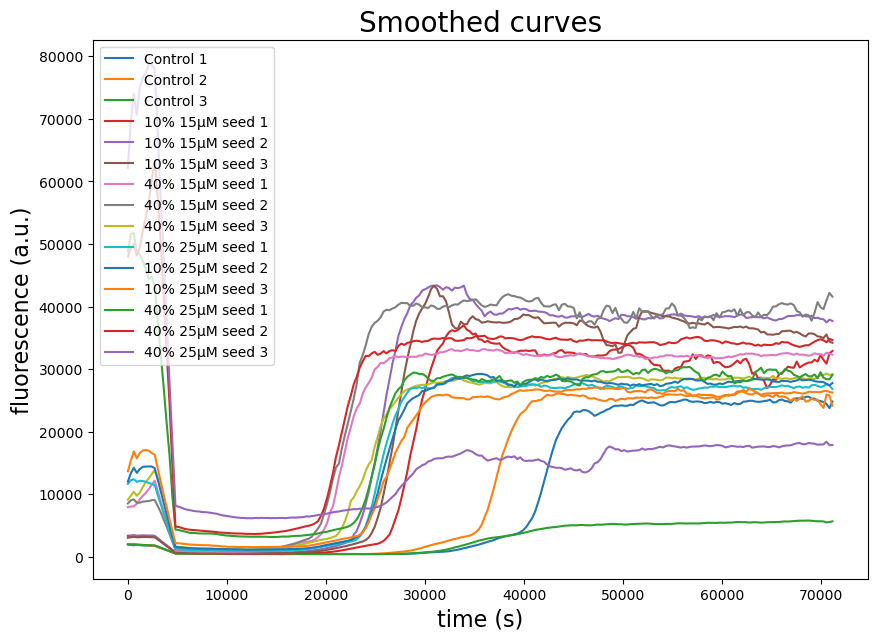

In [6]:
#%% smoothing curves
# calculate smoothed curves parameter averaging is the numer of point taken on each side
smoothed={}
averaging=3
# create a dictionnary with the smoothed curve associated to the label
for tag in experiments:
    smoothed[tag]=smoothing(curves[tag],averaging)

types['smoothed']=smoothed
# graph all smoothed curves
fig,ax = plt.subplots(figsize=(10,7))
for tag in experiments:
    ax.plot(time,smoothed[tag],label=tag)
plt.legend()
plt.ylabel("fluorescence (a.u.)",fontsize=16)
plt.xlabel("time (s)",fontsize=16)
plt.title('Smoothed curves',fontsize=20)
plt.show()

run if you need a different title

graphic title: other custom title


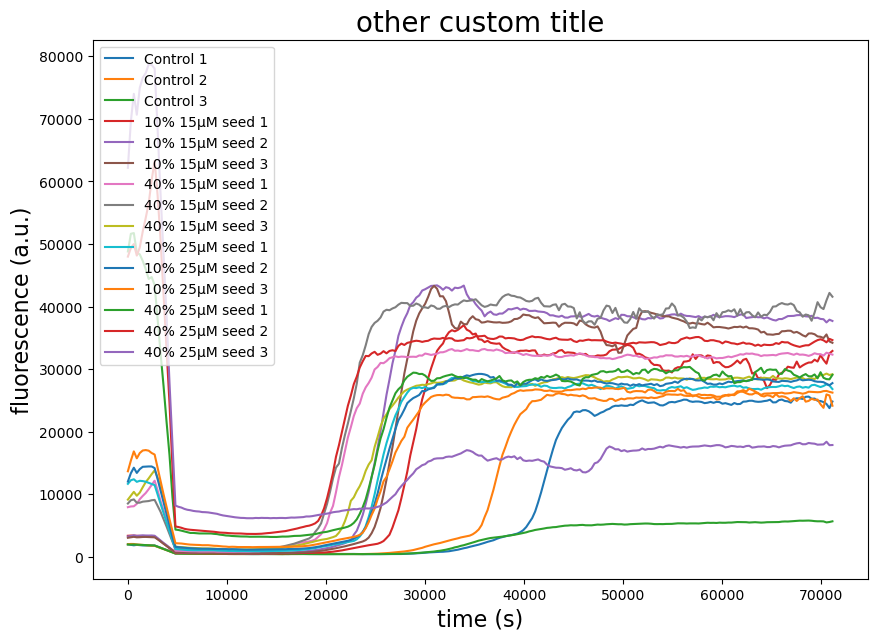

In [7]:
#%%% change title
title=str(input('graphic title: '))
fig,ax = plt.subplots(figsize=(10,7))
for tag in experiments:
    ax.plot(time,smoothed[tag],label=tag)
plt.legend()
plt.ylabel("fluorescence (a.u.)",fontsize=16)
plt.xlabel("time (s)",fontsize=16)
plt.title(title,fontsize=20)
plt.show()

### The curves will be fitted using the logistic function

the function describe a sigmoid curve. Here, parameters have been added to tune the initial value (c), the difference between the initial and final value (A), the point at the center of the transition (m) and the span of the transition (k). The parameters are shown graphically, the variable u was set to 2 so that m+/-u/k correspond to the time at which the derivative at m between the plateau and the baseline.

f(t)=c+A/(1+exp(-k(t-m)))
half time=m, lag time=m-u/k, time plateau=m+u/k
baseline=c, half plateau=c+A/2, plateau=A+c


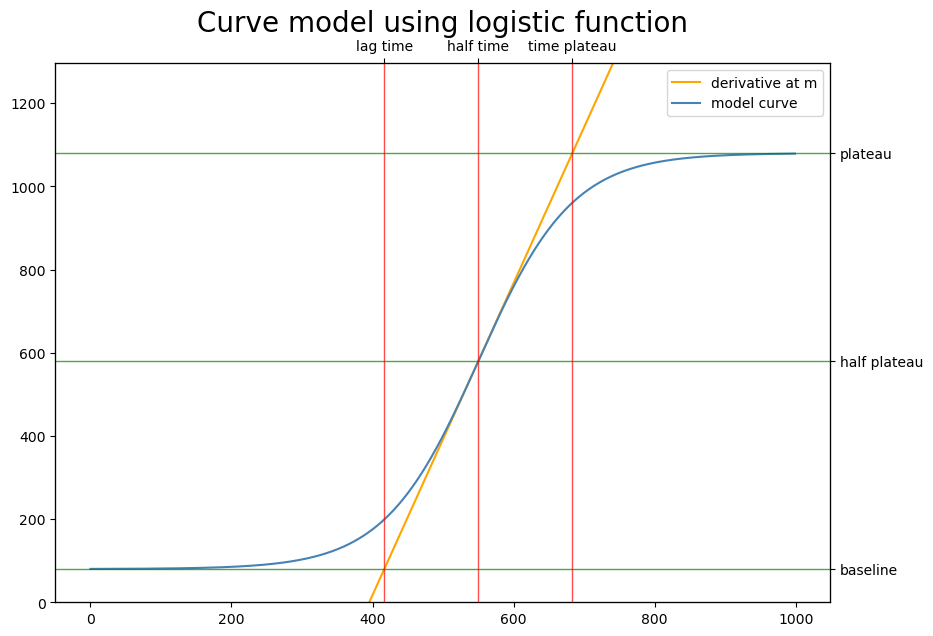

In [8]:
#%% logistic function
# f(t)=c+A/exp(-k(t-m))
step=1
x=np.arange(0,1000,step)
A=1000
m=550
k=.015
c=80

a=(logistic(m+step,A,m,k,c)-logistic(m-step,A,m,k,c))/2
b=c+A/2-a*m
u=2

print('f(t)=c+A/(1+exp(-k(t-m)))')
print('half time=m, lag time=m-u/k, time plateau=m+u/k')
print('baseline=c, half plateau=c+A/2, plateau=A+c')

xticks=[m-u/k,m,m+u/k]
xlabels=['lag time','half time','time plateau']
yticks=[c,c+A/2,A+c]
ylabels=['baseline','half plateau','plateau']
fig,ax = plt.subplots(figsize=(10,7))
plt.plot(x,a*x+b,color='orange',label='derivative at m')
plt.plot(x,logistic(x,A,m,k,c),color='steelblue',label='model curve')
plt.ylim(0,1.2*(A+c))
plt.title('Curve model using logistic function',fontsize=20)
plt.legend()

ax2=ax.twinx().twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_ylim(ax.get_ylim())

for xline in xticks:
    ax2.axvline(xline, color='red', lw=1, alpha=0.7)
for yline in yticks:
    ax2.axhline(yline, color='green', lw=1, alpha=0.7)

ax2.set_xticks(xticks,labels=xlabels)
ax2.set_yticks(yticks,labels=ylabels)
plt.show()

### Detection of flat curves

if the maximum smoothed value is less than "threshold" times the smalllest it is considered as flat

In [9]:
#%% detect flat curves
# test consist in threshold x baseline > plateau
flat=[]
threshold=3
for tag in experiments:
    if max(smoothed[tag])<threshold*min(smoothed[tag]):
        flat.append(tag)

flat=tuple(flat)
if flat!=():
    fig,ax = plt.subplots(figsize=(10,7))
    for tag in experiments:
        if tag in flat:
            ax.plot(time,smoothed[tag],color='black',linestyle='--',label=tag)
        else:
            ax.plot(time,smoothed[tag],label=tag)
    plt.legend()
    plt.ylabel("normalised derivative",fontsize=16)
    plt.xlabel("time (s)",fontsize=16)
    plt.title('The curves in black dashed seem flat',fontsize=20)

    print('\nThose curves did not pass the test: ',list(flat))
    #store flat curve labels in dictionnary
    is_flat=report(flat,experiments,'flat')
    plt.show()

else:
    print('all curves pass the test')


all curves pass the test


### Fitting the curves

the parameters A,m,k,c in the expression f(t)=c+A/(1+exp(-k(t-m))) are determined for each curve

choose type of curves to be fitted:  ['raw', 'smoothed']
raw
Control 1 : A=23798, m=42076, k=8.50e-04, c=831
standard errors: A=125.9, m=56.8, k=3.58e-05, c=78.3 

Control 2 : A=24978, m=37335, k=9.06e-04, c=854
standard errors: A=105.4, m=44.8, k=3.21e-05, c=71.6 

Control 3 : A=4831, m=37431, k=3.38e-04, c=600
standard errors: A=58.8, m=199.8, k=1.99e-05, c=38.5 

10% 15μM seed 1 : A=30958, m=28553, k=1.29e-03, c=1145
standard errors: A=312.6, m=88.6, k=1.29e-04, c=241.6 

10% 15μM seed 2 : A=37912, m=25457, k=1.20e-03, c=1264
standard errors: A=238.7, m=55.9, k=6.98e-05, c=191.5 

10% 15μM seed 3 : A=35982, m=26819, k=1.40e-03, c=1236
standard errors: A=297.6, m=69.0, k=1.18e-04, c=234.9 

40% 15μM seed 1 : A=29337, m=22138, k=1.04e-03, c=2895
standard errors: A=330.6, m=102.6, k=9.74e-05, c=275.6 

40% 15μM seed 2 : A=36652, m=22127, k=9.54e-04, c=2886
standard errors: A=465.1, m=120.4, k=9.55e-05, c=387.9 

40% 15μM seed 3 : A=24826, m=24523, k=8.37e-04, c=3450
standard errors: A=

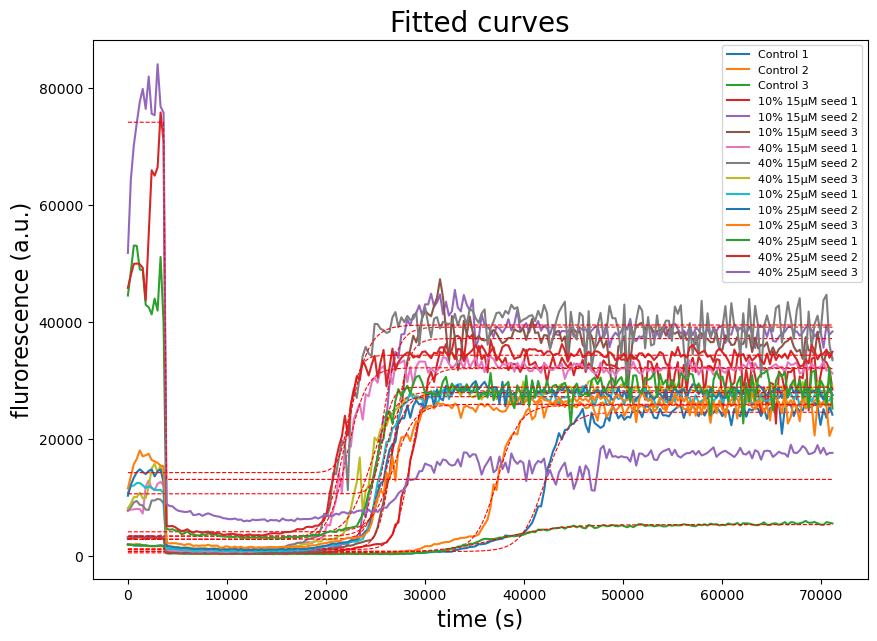

In [10]:
#%% fit the curves
#   def logistic(x,A,m,k,c):
#   f(t)=c+A/(1+exp(-k(t-m)))

sel=pick_type('choose type of curves to be fitted: ',types)

fits={}
error=[]
SEs={}

# plot the fitted curves
fig,ax = plt.subplots(figsize=(10,7))
plt.title('Fitted curves',fontsize=20)
plt.xlabel('time (s)',fontsize=16)
plt.ylabel('flurorescence (a.u.)',fontsize=16)
for tag in experiments:
    curve=types[sel][tag]
    plt.plot(time, curve, label=tag)
    guess=[curve[-1],20000,.003,min(curve)]
    try:
        # calculate curve fitting parameters
        parameters, covariance = curve_fit(logistic, time, curve, p0=guess)
        fits[tag]=parameters
        SE=np.sqrt(np.diag(covariance))
        SEs[tag]=SE
        print(tag,': A=%.0f, m=%.0f, k=%3.2e, c=%.0f' % tuple(parameters))
        print('standard errors: A=%4.1f, m=%4.1f, k=%3.2e, c=%4.1f \n' % tuple(SE))
    # avoid the error if the program can't fit the curve (no aggregation eg)  
    except RuntimeError:
        error.append(tag)
        fits[tag]=np.array([max(curve),0,0,min(curve)])
        SEs[tag]=np.array([np.nan,np.nan,np.nan,np.nan])
        print("curve_fit failed for curve: ",tag)
    
    plt.plot(time, logistic(time, *parameters), 'r--', linewidth=.8)
plt.legend(fontsize=8)
plt.show()

types['fitting']=fits

error=tuple(error)
if error!=():
    print('\nThose curves could not be fitted: ',list(error))
    #store failed fitted curve labels in dictionnary
    is_failed=report(error,experiments,'fitting failed')


### In case of anormally high points at early time

In case the first points of the curves have abnormal values which disturb the fitting, the next cell will allow to determine a zone to exclude from the fitting and recompute the fitting parameters without taking into account the excluded zone. If no problems was spotted before you can just skip it.

insert a lower time boundary: 6000
Control 1 : A=23912, m=42060, k=8.35e-04, c=723
standard errors: A=130.9, m=57.3, k=3.48e-05, c=85.5 

Control 2 : A=25102, m=37319, k=8.92e-04, c=733
standard errors: A=109.2, m=44.4, k=3.08e-05, c=77.8 

Control 3 : A=5077, m=37073, k=3.07e-04, c=373
standard errors: A=30.8, m=97.4, k=8.04e-06, c=21.4 

10% 15μM seed 1 : A=31328, m=28523, k=1.26e-03, c=777
standard errors: A=345.8, m=90.6, k=1.25e-04, c=280.2 

10% 15μM seed 2 : A=38341, m=25426, k=1.17e-03, c=838
standard errors: A=263.5, m=55.9, k=6.64e-05, c=221.7 

10% 15μM seed 3 : A=36324, m=26796, k=1.37e-03, c=896
standard errors: A=333.6, m=70.8, k=1.16e-04, c=276.0 

40% 15μM seed 1 : A=31283, m=21962, k=9.16e-04, c=976
standard errors: A=164.4, m=44.3, k=3.23e-05, c=144.2 

40% 15μM seed 2 : A=38328, m=21975, k=8.68e-04, c=1229
standard errors: A=487.5, m=109.9, k=7.19e-05, c=427.9 

40% 15μM seed 3 : A=26962, m=24219, k=7.04e-04, c=1352
standard errors: A=174.6, m=64.5, k=2.78e-05, c=149

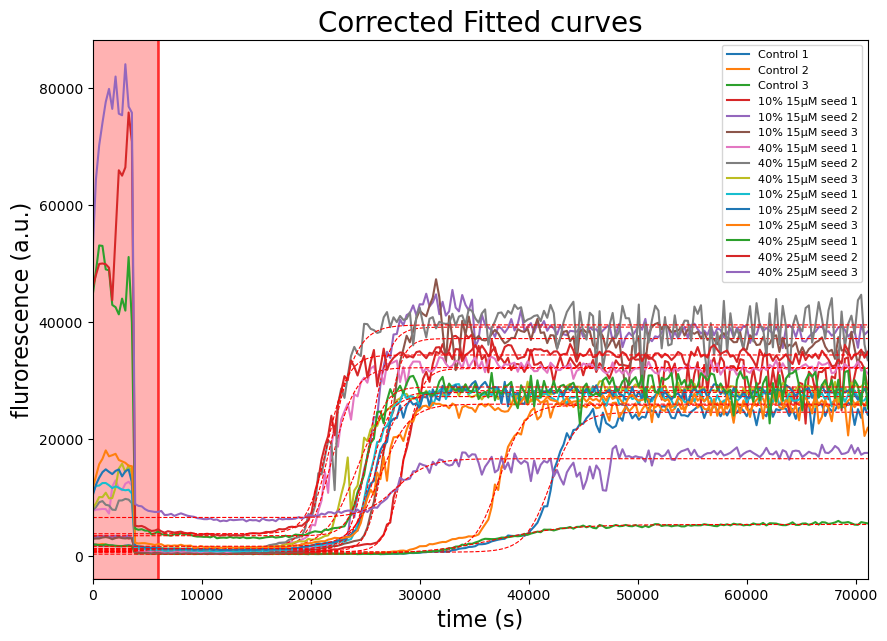

In [11]:
#%% exclude a buffer zone
to_buffer=types[sel]
t0=float(input('insert a lower time boundary: '))
subrange=[i for i in range(len(time)) if time[i] > t0]    

#%%% recalculate fitting from the indicated time limit
fits={}
error=[]
SEs={}

for tag in experiments:
    curve=to_buffer[tag][subrange]
    guess=[np.max(curve),20000,.003,np.min(curve)]
    try:
        # calculate curve fitting parameters
        parameters, covariance = curve_fit(logistic, time[subrange], curve, p0=guess)
        fits[tag]=parameters
        SE=np.sqrt(np.diag(covariance))
        SEs[tag]=SE
        print(tag,': A=%.0f, m=%.0f, k=%3.2e, c=%.0f' % tuple(parameters))
        print('standard errors: A=%.1f, m=%.1f, k=%3.2e, c=%.1f \n' % tuple(SE))
    # avoid the error if the program can't fit the curve (no aggregation eg)  
    except RuntimeError:
        error.append(tag)
        fits[tag]=np.array([max(curve),0,0,min(curve)])
        SEs[tag]=np.array([np.nan,np.nan,np.nan,np.nan])
        print("curve_fit failed for curve: ",tag)

error=tuple(error)
if error!=():
    print('\nThose curves could not be fitted: ',list(error))
    #store failed fitted curve labels in dictionnary
    is_failed=report(error,experiments,'fitting failed')
    
#%%% plot the fitted curves
x=np.arange(np.min(time),np.max(time),10)
fig,ax = plt.subplots(figsize=(10,7))
plt.title('Corrected Fitted curves',fontsize=20)
plt.xlabel('time (s)',fontsize=16)
plt.ylabel('flurorescence (a.u.)',fontsize=16)
ax.axvline(t0, color='red', lw=2, alpha=0.7)
ax.fill_between(x, 0, 1, where=x < t0,color='red', alpha=0.3, transform=ax.get_xaxis_transform())
plt.xlim(x[0],x[-1])
for tag in experiments:
    curve=to_buffer[tag]
    plt.plot(time, curve, label=tag)
    if tag not in error:
        plt.plot(time, logistic(time, *fits[tag]), 'r--', linewidth=.8)
plt.legend(fontsize=8)
plt.show()

### Compile and export the parameters obtained as csv

it also compile the error on each parameter, if a curve was flat or failed to be fitted a line will be in the file mentioning it. The table is exported as a csv file with the suffix "fitting"

In [13]:
#%% compile fitting parameters and errors
#   def logistic(x,A,m,k,c):
# adapt table headers to problems encountered
compil={'headers':['A (a.u.)','σ A (a.u.)','m (s)','σ m (s)','k (s-1)','σ k (s-1)','c (a.u.)','σ c (a.u.)']}
if error!=():
    compil['headers'].insert(0,'error')
if flat!=():
    compil['headers'].insert(0,'flat')

for tag in experiments:
    compil[tag]=[fits[tag][0],SEs[tag][0],fits[tag][1],SEs[tag][1],fits[tag][2],SEs[tag][2],fits[tag][3],SEs[tag][3]]
    if 'error' in compil['headers']:
        compil[tag].insert(0,is_failed[tag])
    if 'flat' in compil['headers']:
        compil[tag].insert(0,is_flat[tag])

# create and save the table
df=pd.DataFrame(compil)
df.to_csv(place+name+' fitting.csv')
print(df)

      headers     Control 1     Control 2     Control 3  10% 15μM seed 1  \
0    A (a.u.)  23912.386971  25102.454132   5076.913230     31328.343184   
1  σ A (a.u.)    130.909664    109.181027     30.751209       345.800552   
2       m (s)  42059.744018  37318.876871  37073.344030     28522.957861   
3     σ m (s)     57.308657     44.403217     97.381035        90.572761   
4     k (s-1)      0.000835      0.000892      0.000307         0.001259   
5   σ k (s-1)      0.000035      0.000031      0.000008         0.000125   
6    c (a.u.)    723.237559    733.160009    372.920581       777.261825   
7  σ c (a.u.)     85.459311     77.848367     21.423687       280.235862   

   10% 15μM seed 2  10% 15μM seed 3  40% 15μM seed 1  40% 15μM seed 2  \
0     38341.199844     36323.920621     31282.581717     38327.933261   
1       263.456593       333.550951       164.382578       487.476716   
2     25425.544859     26796.234652     21961.698005     21975.123403   
3        55.911859     

### Curve parameters definition

the baseline correspond to the variable c, the plateau to the variable A, t1/2 to the variable m. For the lag time from which the aggregation starts and the time plateau corresponding to the stabilisation of the fluorescence I took the half time minus and plus 2 times s (see cell "individual curve control" for graphical control).

In [14]:
#%% parameters redefinitons
baseline={}
plateau={}
t_half={}
lag_time={}
t_plateau={}
f_half={}
extrapolate=[]

# fits[tag] is organised as [A,m,k,c]
for tag in experiments:
    A=fits[tag][0]
    m=fits[tag][1]
    k=fits[tag][2]
    c=fits[tag][3]
    baseline[tag]=c
    plateau[tag]=A+c
    if tag in error:
        t_half[tag]='error'
        lag_time[tag]='error'
        t_plateau[tag]='error'
        f_half[tag]='error'
    else:
        t_half[tag]=m
        lag_time[tag]=m-u/k
        t_plateau[tag]=m+u/k
        f_half[tag]=c+A/2

# look for values where the model has extrapolated the curve
for tag in experiments:
    param_t=[lag_time[tag],t_half[tag],t_plateau[tag]]
    param_f=[baseline[tag],f_half[tag],plateau[tag]]
    for pt in param_t:
        if type(pt)==type(''):
            pass
        else:
            if pt>max(time) or pt<time[0]:
                extrapolate.append(tag)
                break
    for pt in param_f:
        if type(pt)==type(''):
            pass
        else:
            if tag not in extrapolate and pt>max(types[sel][tag]) or pt<min(types[sel][tag]) :
                extrapolate.append(tag)
                break

extrapolate=tuple(extrapolate)
if extrapolate!=():
    print('those curves contain extrapolated parameters: ',extrapolate,'\n')        
    #store curve labels with extrapolated parameters in dictionnary
    is_extra=report(extrapolate,experiments,'some parameters are extrapolated')


### Individual curve control

the cells creates a graphic showing the parameters for the picked curve. The points out of experimental data are represented only with ticks but no line

curve names:  ('Control 1', 'Control 2', 'Control 3', '10% 15μM seed 1', '10% 15μM seed 2', '10% 15μM seed 3', '40% 15μM seed 1', '40% 15μM seed 2', '40% 15μM seed 3', '10% 25μM seed 1', '10% 25μM seed 2', '10% 25μM seed 3', '40% 25μM seed 1', '40% 25μM seed 2', '40% 25μM seed 3')
indicate curve to plot: 10% 15μM seed 2
10% 15μM seed 2 : A=38341, m=25426, k=1.17e-03, c=838
baseline:838, half fluorescence:20009, plateau:39180
lag time:23711, half time:25426, time plateau:27140


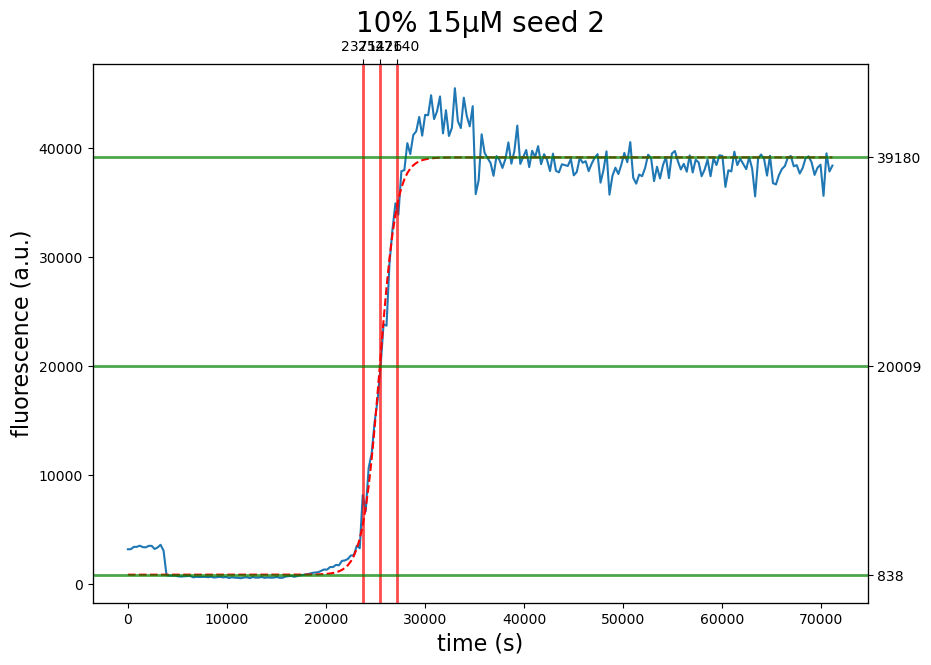

In [15]:
#%% check individually
print('curve names: ',experiments)
tag=str(input('indicate curve to plot: '))
curve=types[sel][tag]

# check that fitting worked to avoid error
if tag in error:
    print('\nfitting did not work')
    fig,ax = plt.subplots(figsize=(10,7))
    ax.plot(time, curve,color='black',linestyle='--', label=tag)
    plt.ylabel("fluorescence (a.u.)",fontsize=16)
    plt.xlabel("time (s)",fontsize=16)
    plt.title(tag,fontsize=20)
else:
    #   def logistic(x,A,m,s,c):
    #   y=A/2*sci.special.erf((x-m)/s)+A/2+c
    print(tag,': A=%.0f, m=%.0f, k=%3.2e, c=%.0f' % tuple(fits[tag]))

    # set ticks corresponding to the different parameters
    param_t=np.array([lag_time[tag],t_half[tag],t_plateau[tag]])
    labels_t=[str(round(i)) for i in param_t]
    ticks_t=[]
    for param in param_t:
        if min(time)<param<max(time):
            ticks_t.append(round(param))
        elif param<min(time):
            ticks_t.append(round(min(time)))
        else:
            ticks_t.append(round(max(time)))
    param_f=[baseline[tag],f_half[tag],plateau[tag]]
    labels_f=[str(round(i)) for i in param_f]
    ticks_f=[]
    if types[sel]=='normalised':
        for param in param_f:
            ticks_f.append(float(format(truc,'3.2f')))
    else:
        for param in param_f:
            if min(smoothed[tag])<param<max(smoothed[tag]):
                ticks_f.append(round(param))
            elif param<min(curve):
                ticks_f.append(round(min(curve)))
            else:
                ticks_f.append(round(max(curve)))
    
    print('baseline:%.0f, half fluorescence:%.0f, plateau:%.0f' % tuple(param_f))
    print('lag time:%.0f, half time:%.0f, time plateau:%.0f' % tuple(param_t))
    if tag in extrapolate:
        print('this curve has extrapolated parameters')           
    # plot the curve
    fig,ax = plt.subplots(figsize=(10,7))
    ax.plot(time, curve, label=tag)
    ax.plot(time, logistic(time, *fits[tag]), 'r--', linewidth=1.5)
    plt.ylabel("fluorescence (a.u.)",fontsize=16)
    plt.xlabel("time (s)",fontsize=16)
    
    # add graphically the parameters not extrapolated
    ax2=ax.twinx().twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_ylim(ax.get_ylim())
    for param in [i for i in param_t if min(time)<=i<=max(time)]:
        ax2.axvline(param, color='red', lw=2, alpha=0.7)
    for param in [i for i in param_f if min(smoothed[tag])<=i<=max(smoothed[tag])]:
        ax2.axhline(param, color='green', lw=2, alpha=0.7)
    ax2.set_xticks(ticks_t,labels=labels_t)
    ax2.set_yticks(ticks_f,labels=labels_f)

    plt.title(tag,fontsize=20)
    plt.show()

### Export analysis

export the table with the parameters, a mention is added if the curve was flat, failed to be fitted or if the programm extrapolate points from the experimental data. The file as the suffix "analysis.csv"

In [16]:
#%%  export analysis
#   def logistic(x,A,m,k,c):
# adapt table headers to problems encountered
compil={'headers':['baseline (a.u.)','plateau (a.u.)','lag time (s)','t1/2 (s)','tplateau (s)']}
if extrapolate!=():
    compil['headers'].insert(0,'extrapolated')
if error!=():
    compil['headers'].insert(0,'error')
if flat!=():
    compil['headers'].insert(0,'flat')

for tag in experiments:
    compil[tag]=[baseline[tag],plateau[tag],lag_time[tag],t_half[tag],t_plateau[tag]]
    if 'extrapolated' in compil['headers']:
        compil[tag].insert(0,is_extra[tag])
    if 'error' in compil['headers']:
        compil[tag].insert(0,is_failed[tag])
    if 'flat' in compil['headers']:
        compil[tag].insert(0,is_flat[tag])

# create and save the table
df=pd.DataFrame(compil)
df.to_csv(place+name+' analysis.csv')
print(df)


           headers     Control 1     Control 2     Control 3  10% 15μM seed 1  \
0  baseline (a.u.)    723.237559    733.160009    372.920581       777.261825   
1   plateau (a.u.)  24635.624530  25835.614141   5449.833811     32105.605009   
2     lag time (s)  39664.402983  35077.249469  30566.123293     26934.050493   
3         t1/2 (s)  42059.744018  37318.876871  37073.344030     28522.957861   
4     tplateau (s)  44455.085053  39560.504273  43580.564767     30111.865228   

   10% 15μM seed 2  10% 15μM seed 3  40% 15μM seed 1  40% 15μM seed 2  \
0       838.447932       896.270433       976.089271      1228.724603   
1     39179.647777     37220.191054     32258.670988     39556.657863   
2     23711.360248     25336.883147     19777.324810     19671.463754   
3     25425.544859     26796.234652     21961.698005     21975.123403   
4     27139.729471     28255.586156     24146.071200     24278.783052   

   40% 15μM seed 3  10% 25μM seed 1  10% 25μM seed 2  10% 25μM seed 3  \
0

### Normalise

you can choose between two methods: normalise the curves individually using their baseline and plateau as 0 and 1 or to use control curves. The control curves can be picked either by copy pasting the labels one by one or using a piece of text common to their labels.
The curves that failed to be fitted will be shown in black dashed lines.

If you want to fit the normalised curves, just run again the fitting cells above, you will be able to choose the normalised curves as template

do you need an individual curve normalistion or based on control curves ? "individual"/"control": control
do you prefer to copy single curve labels or to look for a keyword in the labels ? "single"/"keyword"
keyword
curve labels:  ('Control 1', 'Control 2', 'Control 3', '10% 15μM seed 1', '10% 15μM seed 2', '10% 15μM seed 3', '40% 15μM seed 1', '40% 15μM seed 2', '40% 15μM seed 3', '10% 25μM seed 1', '10% 25μM seed 2', '10% 25μM seed 3', '40% 25μM seed 1', '40% 25μM seed 2', '40% 25μM seed 3')
write a subword to look in the labels
target subword 1 : 
Control
current selection:  ['Control 1', 'Control 2', 'Control 3']  press enter to end the selection
target subword 2 : 

current selection:  ['Control 1', 'Control 2', 'Control 3']  press enter to end the selection
Those curves were used as controls:  ['Control 1', 'Control 2', 'Control 3']


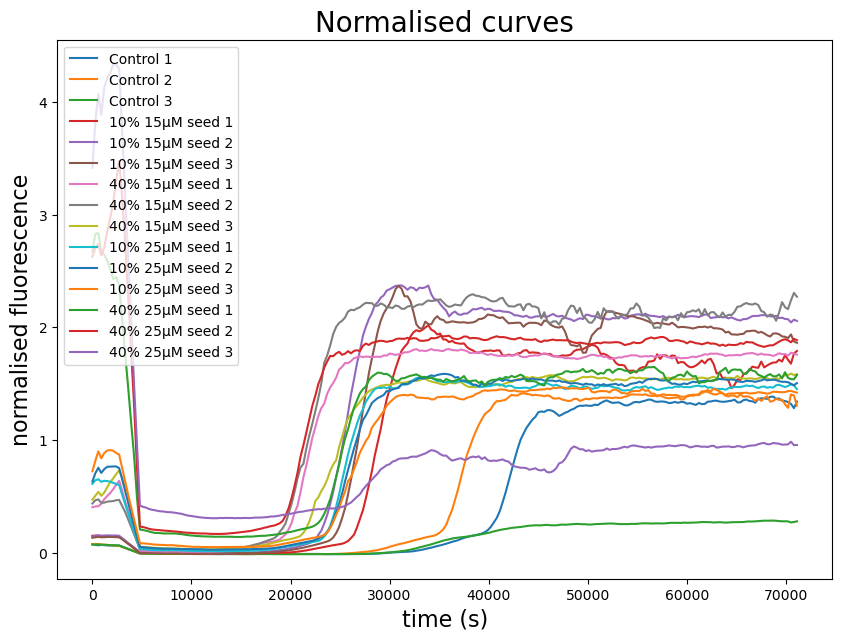

In [17]:
#%% normalise
Normalised={}

# determine type of normalisation wanted
Ct_type=str(input('do you need an individual curve normalistion or based on control curves ? "individual"/"control": '))
if Ct_type=="control":
    # allow to pick the controls based on two methods
    Ct=pick_curve(experiments)
    print('Those curves were used as controls: ',Ct)
    maxi=0
    mini=0
    for ct in Ct:
        maxi+=plateau[ct]
        mini+=baseline[ct]
    maxi=maxi/len(Ct)
    mini=mini/len(Ct)
    for tag in experiments:
        Normalised[tag]=normalise(smoothed[tag],maxi,mini)
if Ct_type=="individual":
    for tag in experiments:
        if tag in is_flat or tag in is_failed:
            Normalised[tag]=normalise(smoothed[tag],plateau[tag],baseline[tag])

# graph all normalised curves
fig,ax = plt.subplots(figsize=(10,7))
for tag in experiments:
    if tag not in error or tag not in flat:
        ax.plot(time,Normalised[tag],label=tag)
    else:
        try:
            ax.plot(time,Normalised[tag],color='black',linestyle='--',label=tag)
        except:
            pass
plt.legend()
plt.ylabel("normalised fluorescence",fontsize=16)
plt.xlabel("time (s)",fontsize=16)
plt.title('Normalised curves',fontsize=20)
plt.show()

types['normalised']=Normalised

### Export curves

create a table with all points of all curves created and export it as csv file with the suffix "curves"

In [18]:
#%% export curves
table={'time (s)':time}
headers=['time']
for c in types.keys():
    for tag in experiments:
        if c=='fitting':
            if tag in error:
                pass
            else:
                table[tag+' '+c]=logistic(time,types[c][tag][0],types[c][tag][1],types[c][tag][2],types[c][tag][3])
        else:
            headers.append(tag+' '+c)
            table[tag+' '+c]=types[c][tag]
table=pd.DataFrame(table)
df.to_csv(place+name+' curves.csv')
print(table)

     time (s)  Control 1 raw  Control 2 raw  Control 3 raw  \
0         0.0           2088           2002           1954   
1       300.1           2031           1990           1978   
2       600.1           1836           2023           1942   
3       900.1           1861           2124           1900   
4      1200.2           1798           1972           2037   
..        ...            ...            ...            ...   
233   69908.6          22449          26023           5417   
234   70208.6          25162          26452           5393   
235   70508.7          23669          26597           5852   
236   70808.7          25612          25673           5750   
237   71108.8          24210          26938           5632   

     10% 15μM seed 1 raw  10% 15μM seed 2 raw  10% 15μM seed 3 raw  \
0                   3264                 3174                 2997   
1                   3419                 3179                 3051   
2                   3377                 3392

### Custom graphics

allows to choose which curves to plot with the same system as before and the type of curves

select the type of curves to plot:  ['raw', 'smoothed', 'fitting', 'normalised']
fitting
do you prefer to copy single curve labels or to look for a keyword in the labels ? "single"/"keyword"
single
curve labels:  ('Control 1', 'Control 2', 'Control 3', '10% 15μM seed 1', '10% 15μM seed 2', '10% 15μM seed 3', '40% 15μM seed 1', '40% 15μM seed 2', '40% 15μM seed 3', '10% 25μM seed 1', '10% 25μM seed 2', '10% 25μM seed 3', '40% 25μM seed 1', '40% 25μM seed 2', '40% 25μM seed 3')
copy paste curve label:
curve label 1 : press enter to end the selection
Control 1
curve label 2 : press enter to end the selection
Control 2
curve label 3 : press enter to end the selection
Control 3
curve label 4 : press enter to end the selection

insert title: graph control fitted curves


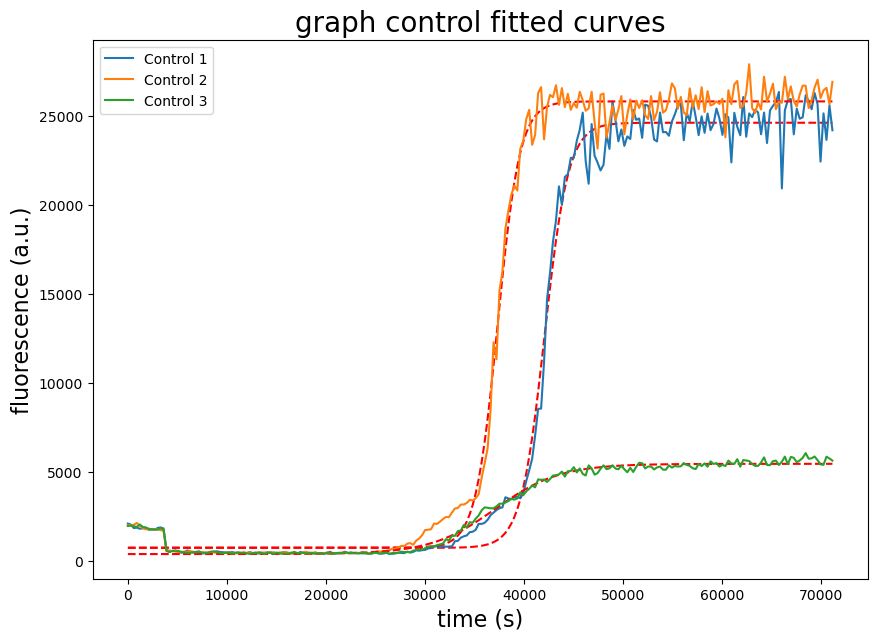

In [19]:
#%% custom graph
select=pick_type('select the type of curves to plot: ',types)
to_plot=pick_curve(experiments)
# produce the graphic
title=str(input('insert title: '))
fig,ax = plt.subplots(figsize=(10,7))
for wanted in to_plot:
    if select=='fitting':
        if wanted in error:
            ax.plot(time,smoothed[wanted],color='black',linestyle='--',label=wanted)
        else:
            ax.plot(time,logistic(time,*fits[wanted]),'r--')
            ax.plot(time,types[sel][wanted],label=wanted)
    else:
        ax.plot(time,types[select][wanted],label=wanted)            
plt.legend()
y_label={"raw": "fluorescence (a.u.)", "smoothed": "fluorescence (a.u.)","derivative": "derivative (a.u./s)","norm_derivative": "normalised derivative", "normalised": "normalised fluorescence","fitting":"fluorescence (a.u.)"}
plt.ylabel(y_label[select],fontsize=16)
plt.xlabel("time (s)",fontsize=16)
plt.title(title,fontsize=20)
plt.show()
